# Maken generieren

## Brain mask

In [84]:
import numpy as np
import matplotlib.pyplot as plt

data_for_mask = np.load('MetabMaps/Lesion_Double_GT/water_amp_Lesion_Double_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_mask)              # ignoriert NaNs
threshold = 0.01 * mx
brain_mask = (data_for_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
brain_mask[np.isnan(data_for_mask)] = 0

# Lesion mask (big)

In [85]:
import nibabel as nib
import numpy as np

# NIfTI laden
nii = nib.load("Lesion_Double_lr.nii")

# als NumPy-Array (float64)
Lesion_mask = nii.get_fdata()

Lesion_mask = np.swapaxes(Lesion_mask, -1, 0)

print(Lesion_mask.shape, Lesion_mask.dtype)


(21, 22, 22) float64


# Lac mask

In [86]:
# data_for_Les_mask = np.load('MetabMaps/Lesion_Double_GT/Lac_amp_Lesion_Double_GT_Orig.npy')[...,-1]

# mx = np.nanmax(data_for_Les_mask)              # ignoriert NaNs
# threshold = 0.2 * mx
# Lesion_mask = (data_for_Les_mask > threshold).astype(np.uint8)

# # optional: NaNs explizit auf 0 setzen
# Lesion_mask[np.isnan(data_for_Les_mask)] = 0

# Define helper Function for RMSE over time

In [87]:
import os
import numpy as np

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.load(path)

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

# def relative_rmse(gt, pred, mask, eps=1e-12):
#     """
#     gt, pred: arrays with shape (x,y,z)
#     mask: boolean or {0,1} array broadcastable to gt without time OR with time
#     returns: rRMSE
#     """

#     mask = mask.astype(bool) & np.isfinite(gt) & np.isfinite(pred)
#     rmse = np.sqrt(np.mean((gt[mask] - pred[mask])**2))/(np.max(gt[mask])-(np.min(gt[mask])))

#     return rmse

def relative_rmse(gt, pred, mask, eps=1e-12):
    """
    gt, pred: arrays with shape (x,y,z)
    mask: array in {0,1} OR [0,1] (PV weights), broadcastable to gt
    returns: relative RMSE
    """

    m = np.asarray(mask, dtype=np.float64)
    valid = np.isfinite(gt) & np.isfinite(pred) & np.isfinite(m) & (m > 0)

    if not np.any(valid):
        return np.nan

    diff2 = (gt[valid] - pred[valid])**2
    rmse = np.sqrt(np.sum(m[valid] * diff2) / (np.sum(m[valid]) + eps))

    # same normalization logic as before, but restricted to ROI
    denom = (np.max(gt[valid]) - np.min(gt[valid])) + eps

    return rmse / denom

def relative_rmse_time(gt, pred, mask, eps=1e-12):
    """
    Returns relative RMSE as a function of time (last index)
    """
    T = gt.shape[-1]
    RMSE = []

    for i in range(0,T):
        RMSE.append(relative_rmse(gt[..., i], pred[..., i], mask, eps))

    return RMSE

def relative_rmse_time_stats(gt, preds, mask, eps=1e-12):
    """
    preds: list of predictions with same shape as gt

    returns:
        mean_rmse_time, std_rmse_time
    """
    rmses = np.stack([relative_rmse_time(gt, p, mask, eps) for p in preds], axis=0)
    return rmses.mean(axis=0), rmses.std(axis=0)

# ---------- helper ----------
def compute_mean_std_rrmse_time(root, metab, mask, gt_method, rep_methods, suffix="Orig", eps=1e-12):
    """
    rep_methods: dict label -> list of method-folders (reps)
    returns: dict label -> (mean(T,), std(T,))
    """
    gt = load_metab_map(root, gt_method, metab, suffix)

    out = {}
    for label, reps in rep_methods.items():
        preds = load_multiple_metab_maps(root, reps, metab, suffix)
        mean_t, std_t = relative_rmse_time_stats(gt, preds, mask, eps)
        out[label] = (np.asarray(mean_t), np.asarray(std_t))
    return out




Metabo = "Lac" 
MASK = Lesion_mask # brain_mask

# Noisy_Reps = ["Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy"]
# Deep_Reps = ["Lesion_Double_deep_tMPPCA_5D", "Lesion_Double_tMPPCA_5D", "Lesion_Double_deep_tMPPCA_5D"]
# tMPPCA_Reps = ["Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D"]

GT_Lac = load_metab_map("MetabMaps", "Lesion_Double_GT", f"{Metabo}")


# Noisy_Lac = load_metab_map("MetabMaps", "Lesion_Double_Noisy", f"{Metabo}")
# Deep_Lac = load_metab_map("MetabMaps", "Lesion_Double_deep_tMPPCA_5D", f"{Metabo}")
# tMPPCA_Lac = load_metab_map("MetabMaps", "Lesion_Double_tMPPCA_5D", f"{Metabo}")

# Noisy = relative_rmse_time(GT_Lac, Noisy_Lac, MASK)
# Deep = relative_rmse_time(GT_Lac, Deep_Lac, MASK)
# tMPPCA = relative_rmse_time(GT_Lac, tMPPCA_Lac, MASK)


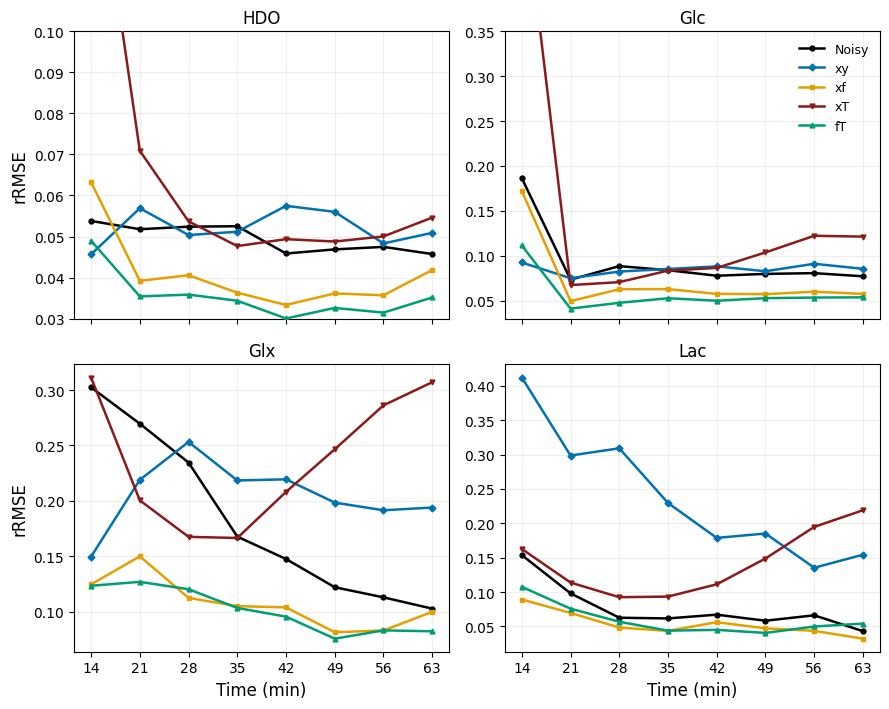

In [88]:
# ===================== USER SETTINGS =====================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

# ----------- EXACTLY THE 5 METHODS YOU WANT -----------
Noisy_Reps = ["Lesion_double_noisy_6_uncorrelated"]
xy_Reps    = ["Lesion_double_deep_xy_6_uncorrelated"]
xf_Reps    = ["Lesion_double_deep_xf_6_uncorrelated"]
xT_Reps    = ["Lesion_double_deep_xT_6_uncorrelated"]
fT_Reps    = ["Lesion_double_deep_fT_6_uncorrelated"]

rep_methods = {
    "Noisy": Noisy_Reps,
    "xy":    xy_Reps,
    "xf":    xf_Reps,
    "xT":    xT_Reps,
    "fT":    fT_Reps,
}

DISPLAY_METHOD = {
    "Noisy": "Noisy",
    "xy":    "xy",
    "xf":    "xf",
    "xT":    "xT",
    "fT":    "fT",
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

# ===================== PLOTTING =====================

DEFAULT_COLORS = {
    "Noisy": "#000000",   # black
    "xy":    "#0072B2",   # blue
    "xf":    "#E69F00",   # green  009E73
    "xT":    "#8B1A1A",   # dark red
    "fT":    "#009E73",   # orange "#E69F00
}

DEFAULT_MARKERS = {
    "Noisy": "o",
    "xy":    "D",
    "xf":    "s",
    "xT":    "v",
    "fT":    "^",
}

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.2), sharex=True)
axes = axes.ravel()

lw, ms = 1.8, 3.5

# ---------- LEGEND ----------
legend_handles = [
    Line2D(
        [0], [0],
        color=DEFAULT_COLORS[k],
        marker=DEFAULT_MARKERS[k],
        linestyle="-",
        lw=lw,
        ms=ms,
        label=DISPLAY_METHOD[k],
    )
    for k in rep_methods.keys()
]

# ---------- PLOTS ----------
for ax, (metab, mask) in zip(axes, metabs):

    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    x = np.asarray(time_axis)

    for lab in rep_methods.keys():
        mean_t, _ = curves[lab]
        mean_t = np.asarray(mean_t)

        ax.plot(
            x, mean_t,
            color=DEFAULT_COLORS[lab],
            marker=DEFAULT_MARKERS[lab],
            linestyle="-",
            lw=lw,
            ms=ms,
            zorder=3,
        )

    ax.set_title(DISPLAY_NAME.get(metab, metab))
    ax.grid(True, alpha=0.2)
    ax.set_xticks(x)

    # match your previous y-limits
    if metab == "water":
        ax.set_ylim(0.03, 0.10)
    elif metab == "Glc":
        ax.set_ylim(0.03, 0.35)

    if ax in (axes[0], axes[2]):
        ax.set_ylabel("rRMSE")
    else:
        ax.set_ylabel("")

axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

fig.tight_layout()
plt.savefig("rrmseSupplement.pdf")
plt.show()


# Compare spectra

In [89]:
import numpy as np 
import matplotlib.pyplot as plt

GT = np.load("MetabMaps/Lesion_Double_GT/Spectra_Lesion_Double_GT.npy")[...,:166,:] # cropped to 1 to 8 ppm instead of 0.5 to 8
xy = np.load("MetabMaps/Lesion_double_deep_xy_6_uncorrelated/Spectra_Lesion_double_deep_xy_6_uncorrelated.npy")[...,:166,:]
xT = np.load("MetabMaps/Lesion_double_deep_xT_6_uncorrelated/Spectra_Lesion_double_deep_xT_6_uncorrelated.npy")[...,:166,:]
xf = np.load("MetabMaps/Lesion_double_deep_xf_6_uncorrelated/Spectra_Lesion_double_deep_xf_6_uncorrelated.npy")[...,:166,:]
fT = np.load("MetabMaps/Lesion_double_deep_fT_6_uncorrelated/Spectra_Lesion_double_deep_fT_6_uncorrelated.npy")[...,:166,:]

/tmp/ipykernel_1953485/131761985.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


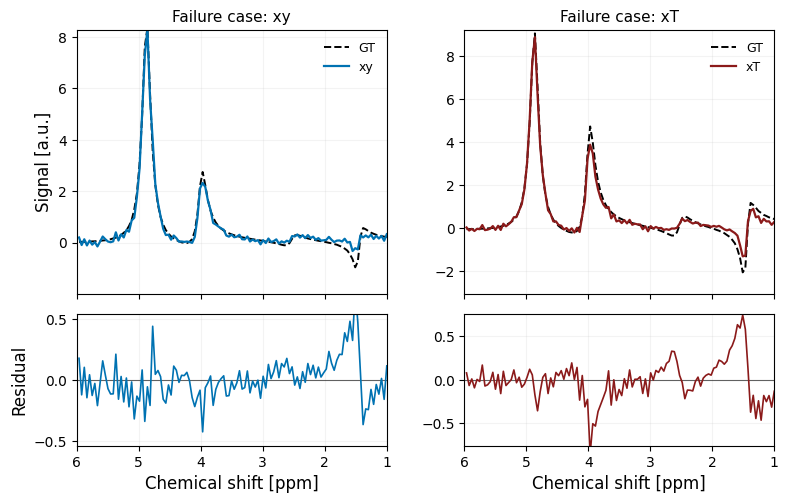

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- settings ----------------
x, y, z = 14, 11, 15
t_left  = 2   # xy failure case
t_right = 7   # xT failure case

ppm = np.linspace(8, 1, GT.shape[3])

ppm_lo, ppm_hi = 6.0, 1.0
mask = (ppm >= ppm_hi) & (ppm <= ppm_lo)
ppm_w = ppm[mask]

scale = 1e-3  # divide by 1000

def robust_ylim_upper(arr, p_lo=1.0, p_hi=98.5, pad_up=0.25, pad_lo=0.20):
    lo, hi = np.percentile(arr, [p_lo, p_hi])
    rng = hi - lo
    return lo - pad_lo * rng, hi + pad_up * rng

def symmetric_ylim(arr, p=98.5, pad=0.15):
    m = np.percentile(np.abs(arr), p)
    return -(1 + pad) * m, (1 + pad) * m

# ---------------- extract spectra (real part) ----------------
gt_L = GT[x, y, z, :, t_left].real[mask] * scale
xy_L = xy[x, y, z, :, t_left].real[mask] * scale
res_L = xy_L - gt_L

gt_R = GT[x, y, z, :, t_right].real[mask] * scale
xT_R = xT[x, y, z, :, t_right].real[mask] * scale
res_R = xT_R - gt_R

yl_spec_L = robust_ylim_upper(np.concatenate([gt_L, xy_L]))
yl_spec_R = robust_ylim_upper(np.concatenate([gt_R, xT_R]))
yl_res_L  = symmetric_ylim(res_L)
yl_res_R  = symmetric_ylim(res_R)

# ---------------- plot layout: EXACT width match (9.0 inch) ----------------
# height chosen so that top row height ~= 3.6 inch (matches one row in 9.0x7.2 2x2 figure)
fig = plt.figure(figsize=(9.0, 5.4))
gs = fig.add_gridspec(2, 2, height_ratios=[2.0, 1.0], wspace=0.25, hspace=0.10)

axL  = fig.add_subplot(gs[0, 0])
axLr = fig.add_subplot(gs[1, 0], sharex=axL)

axR  = fig.add_subplot(gs[0, 1])
axRr = fig.add_subplot(gs[1, 1], sharex=axR)

# LEFT: xy
axL.plot(ppm_w, gt_L, '--', color='black', lw=1.4, label='GT')
axL.plot(ppm_w, xy_L, color='#0072B2', lw=1.6, label='xy')
axL.set_title("Failure case: xy", fontsize=11)
axL.set_xlim(ppm_lo, ppm_hi)
axL.set_ylim(*yl_spec_L)
axL.grid(True, alpha=0.15)
axL.legend(frameon=False, loc="upper right", fontsize=9)
axL.set_ylabel("Signal [a.u.]")

axLr.axhline(0, color='black', lw=0.8, alpha=0.6)
axLr.plot(ppm_w, res_L, color='#0072B2', lw=1.2)
axLr.set_ylim(*yl_res_L)
axLr.grid(True, alpha=0.15)
axLr.set_xlabel("Chemical shift [ppm]")
axLr.set_ylabel("Residual")

# RIGHT: xT
axR.plot(ppm_w, gt_R, '--', color='black', lw=1.4, label='GT')
axR.plot(ppm_w, xT_R, color='#8B1A1A', lw=1.6, label='xT')
axR.set_title("Failure case: xT", fontsize=11)
axR.set_xlim(ppm_lo, ppm_hi)
axR.set_ylim(*yl_spec_R)
axR.grid(True, alpha=0.15)
axR.legend(frameon=False, loc="upper right", fontsize=9)

axRr.axhline(0, color='black', lw=0.8, alpha=0.6)
axRr.plot(ppm_w, res_R, color='#8B1A1A', lw=1.2)
axRr.set_ylim(*yl_res_R)
axRr.grid(True, alpha=0.15)
axRr.set_xlabel("Chemical shift [ppm]")

# remove top x tick labels
plt.setp(axL.get_xticklabels(), visible=False)
plt.setp(axR.get_xticklabels(), visible=False)

plt.tight_layout()
plt.savefig("SpectralConsistency_FailureCases_withResiduals.pdf")
plt.show()


/tmp/ipykernel_1953485/167496694.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


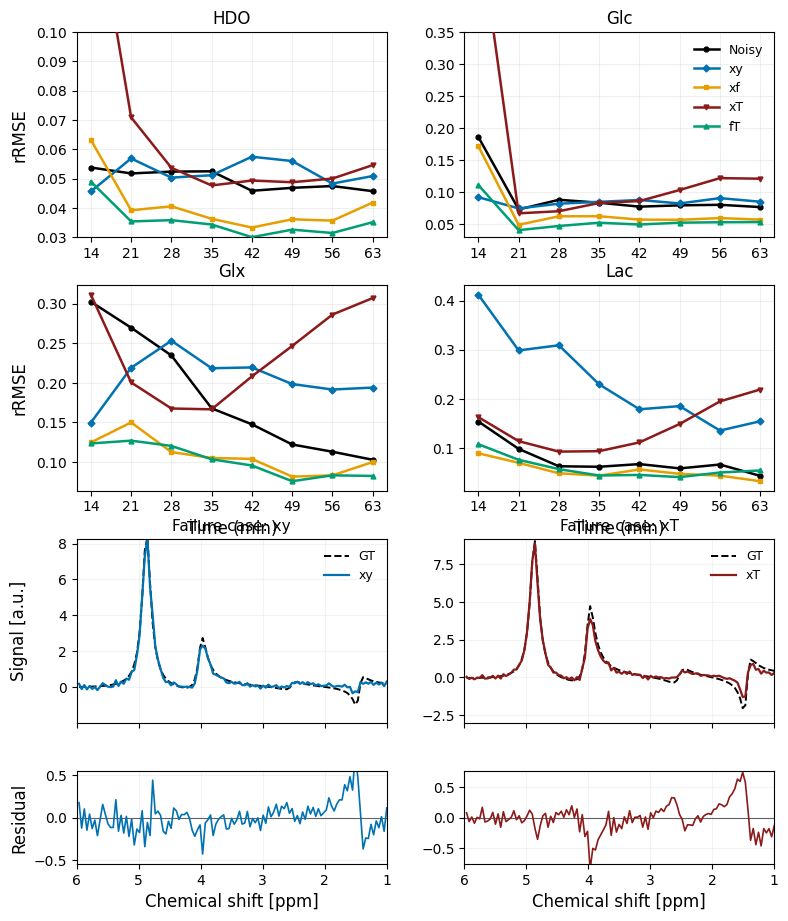

In [91]:
# ===================== ONE-FIGURE VERSION (COPY/PASTE) =====================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===================== USER SETTINGS (FROM FIGURE 1) =====================
root = "MetabMaps"
gt_method = "Lesion_Double_GT"
suffix = "Orig"

# ----------- EXACTLY THE 5 METHODS YOU WANT -----------
Noisy_Reps = ["Lesion_double_noisy_6_uncorrelated"]
xy_Reps    = ["Lesion_double_deep_xy_6_uncorrelated"]
xf_Reps    = ["Lesion_double_deep_xf_6_uncorrelated"]
xT_Reps    = ["Lesion_double_deep_xT_6_uncorrelated"]
fT_Reps    = ["Lesion_double_deep_fT_6_uncorrelated"]

rep_methods = {
    "Noisy": Noisy_Reps,
    "xy":    xy_Reps,
    "xf":    xf_Reps,
    "xT":    xT_Reps,
    "fT":    fT_Reps,
}

DISPLAY_METHOD = {
    "Noisy": "Noisy",
    "xy":    "xy",
    "xf":    "xf",
    "xT":    "xT",
    "fT":    "fT",
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

time_axis = np.array([14, 21, 28, 35, 42, 49, 56, 63])

# ===================== PLOTTING STYLE =====================
DEFAULT_COLORS = {
    "Noisy": "#000000",   # black
    "xy":    "#0072B2",   # blue
    "xf":    "#E69F00",   # orange
    "xT":    "#8B1A1A",   # dark red
    "fT":    "#009E73",   # green
}

DEFAULT_MARKERS = {
    "Noisy": "o",
    "xy":    "D",
    "xf":    "s",
    "xT":    "v",
    "fT":    "^",
}

mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

lw, ms = 1.8, 3.5

# ===================== SETTINGS (FROM FIGURE 2) =====================
x, y, z = 14, 11, 15
t_left  = 2   # xy failure case
t_right = 7   # xT failure case

ppm = np.linspace(8, 1, GT.shape[3])

ppm_lo, ppm_hi = 6.0, 1.0
ppm_mask = (ppm >= ppm_hi) & (ppm <= ppm_lo)
ppm_w = ppm[ppm_mask]

scale = 1e-3  # divide by 1000

def robust_ylim_upper(arr, p_lo=1.0, p_hi=98.5, pad_up=0.25, pad_lo=0.20):
    lo, hi = np.percentile(arr, [p_lo, p_hi])
    rng = hi - lo
    return lo - pad_lo * rng, hi + pad_up * rng

def symmetric_ylim(arr, p=98.5, pad=0.15):
    m = np.percentile(np.abs(arr), p)
    return -(1 + pad) * m, (1 + pad) * m

# ===================== CREATE ONE SINGLE FIGURE =====================
# Height ~ (7.2 + 3.6) = 10.8 to mimic "figure2 under figure1"
fig = plt.figure(figsize=(9.0, 10.8))

# 4 rows x 2 cols:
# rows 0-1 : rRMSE 2x2
# row 2    : spectra (xy left, xT right)
# row 3    : residuals (xy left, xT right)
gs = fig.add_gridspec(
    4, 2,
    height_ratios=[1.0, 1.0, 0.9, 0.45],
    hspace=0.28,
    wspace=0.25
)

# ===================== TOP: rRMSE 2x2 =====================
axes = np.array([
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
])

# ---------- LEGEND ----------
legend_handles = [
    Line2D(
        [0], [0],
        color=DEFAULT_COLORS[k],
        marker=DEFAULT_MARKERS[k],
        linestyle="-",
        lw=lw,
        ms=ms,
        label=DISPLAY_METHOD[k],
    )
    for k in rep_methods.keys()
]

# ---------- PLOTS ----------
for ax, (metab, mask) in zip(axes, metabs):

    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    xt = np.asarray(time_axis)

    for lab in rep_methods.keys():
        mean_t, _ = curves[lab]
        mean_t = np.asarray(mean_t)

        ax.plot(
            xt, mean_t,
            color=DEFAULT_COLORS[lab],
            marker=DEFAULT_MARKERS[lab],
            linestyle="-",
            lw=lw,
            ms=ms,
            zorder=3,
        )

    ax.set_title(DISPLAY_NAME.get(metab, metab))
    ax.grid(True, alpha=0.2)
    ax.set_xticks(xt)

    # match your previous y-limits
    if metab == "water":
        ax.set_ylim(0.03, 0.10)
    elif metab == "Glc":
        ax.set_ylim(0.03, 0.35)

    if ax in (axes[0], axes[2]):
        ax.set_ylabel("rRMSE")
    else:
        ax.set_ylabel("")

axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

axes[1].legend(handles=legend_handles, frameon=False, loc="upper right")

# ===================== BOTTOM: Failure cases (spectra + residuals) =====================
# ---------------- extract spectra (real part) ----------------
gt_L  = GT[x, y, z, :, t_left].real[ppm_mask] * scale
xy_L  = xy[x, y, z, :, t_left].real[ppm_mask] * scale
res_L = xy_L - gt_L

gt_R  = GT[x, y, z, :, t_right].real[ppm_mask] * scale
xT_R  = xT[x, y, z, :, t_right].real[ppm_mask] * scale
res_R = xT_R - gt_R

yl_spec_L = robust_ylim_upper(np.concatenate([gt_L, xy_L]))
yl_spec_R = robust_ylim_upper(np.concatenate([gt_R, xT_R]))
yl_res_L  = symmetric_ylim(res_L)
yl_res_R  = symmetric_ylim(res_R)

# ---------------- axes from GridSpec ----------------
axL  = fig.add_subplot(gs[2, 0])
axR  = fig.add_subplot(gs[2, 1], sharex=axL)

axLr = fig.add_subplot(gs[3, 0], sharex=axL)
axRr = fig.add_subplot(gs[3, 1], sharex=axR)

# LEFT: xy
axL.plot(ppm_w, gt_L, '--', color='black', lw=1.4, label='GT')
axL.plot(ppm_w, xy_L, color=DEFAULT_COLORS["xy"], lw=1.6, label='xy')
axL.set_title("Failure case: xy", fontsize=11)
axL.set_xlim(ppm_lo, ppm_hi)
axL.set_ylim(*yl_spec_L)
axL.grid(True, alpha=0.15)
axL.legend(frameon=False, loc="upper right", fontsize=9)
axL.set_ylabel("Signal [a.u.]")

axLr.axhline(0, color='black', lw=0.8, alpha=0.6)
axLr.plot(ppm_w, res_L, color=DEFAULT_COLORS["xy"], lw=1.2)
axLr.set_ylim(*yl_res_L)
axLr.grid(True, alpha=0.15)
axLr.set_xlabel("Chemical shift [ppm]")
axLr.set_ylabel("Residual")

# RIGHT: xT
axR.plot(ppm_w, gt_R, '--', color='black', lw=1.4, label='GT')
axR.plot(ppm_w, xT_R, color=DEFAULT_COLORS["xT"], lw=1.6, label='xT')
axR.set_title("Failure case: xT", fontsize=11)
axR.set_xlim(ppm_lo, ppm_hi)
axR.set_ylim(*yl_spec_R)
axR.grid(True, alpha=0.15)
axR.legend(frameon=False, loc="upper right", fontsize=9)

axRr.axhline(0, color='black', lw=0.8, alpha=0.6)
axRr.plot(ppm_w, res_R, color=DEFAULT_COLORS["xT"], lw=1.2)
axRr.set_ylim(*yl_res_R)
axRr.grid(True, alpha=0.15)
axRr.set_xlabel("Chemical shift [ppm]")

# remove top x tick labels for the spectra row
plt.setp(axL.get_xticklabels(), visible=False)
plt.setp(axR.get_xticklabels(), visible=False)

# final spacing
fig.align_ylabels()
fig.tight_layout()

plt.savefig("Combined_rRMSE_plus_FailureCases.pdf")
plt.show()
